# Cross-Sectional Momentum Factor Library — Full Research Report

This notebook runs the complete research pipeline end-to-end:

1. Data & Universe
2. Factor Definitions
3. Quantile Portfolio Analysis
4. Factor Comparison
5. Risk-Adjusted Performance (Fama-French)
6. Robustness (Sub-periods, Rolling Sharpe, Multiple Testing)
7. Turnover & Transaction Costs
8. Conclusions & Limitations

**Run all cells top-to-bottom.** Data is fetched automatically from Yahoo Finance and Kenneth French's data library.

In [1]:
import sys, os
# Ensure the project root is on the path
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi': 120,
    'figure.figsize': (12, 5),
})

import config
from src.data_loader import fetch_price_data, fetch_risk_free_rate, fetch_sector_map
from src.universe import apply_universe_filters
from src.backtester import MomentumBacktester
from src.analytics import (
    compute_stats,
    compute_rolling_sharpe,
    fama_french_regression,
    multiple_testing_adjustment,
    sub_period_analysis,
    _load_ff_factors,
)

print('Libraries loaded. Starting pipeline...')

Libraries loaded. Starting pipeline...


---
## Section 1 — Data & Universe

In [3]:
# ── 1.1 Fetch price data ──────────────────────────────────────────────────────
prices = fetch_price_data(
    config.UNIVERSE_TICKERS,
    config.START_DATE,
    config.END_DATE,
)

benchmark_df = fetch_price_data(
    [config.BENCHMARK],
    config.START_DATE,
    config.END_DATE,
)
benchmark = benchmark_df.squeeze()
benchmark.name = 'SPY'

risk_free = fetch_risk_free_rate(config.START_DATE, config.END_DATE)

print(f'Price matrix shape: {prices.shape}')
print(f'Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Benchmark observations: {len(benchmark)}')
print(f'Risk-free observations: {len(risk_free)}')

2026-04-06 16:48:38,280 [INFO] Downloading price data for 168 tickers from 2005-01-01 to 2024-12-31 …
[**                     4%                       ]  6 of 168 completed2026-04-06 16:48:39,998 [ERROR] $MMC: possibly delisted; no timezone found
[****                   9%                       ]  15 of 168 completed2026-04-06 16:48:40,696 [ERROR] $WRK: possibly delisted; no timezone found
[*******               14%                       ]  24 of 168 completed2026-04-06 16:48:41,250 [ERROR] $K: possibly delisted; no timezone found
[**********            20%                       ]  33 of 168 completed2026-04-06 16:48:41,935 [ERROR] $XLNX: possibly delisted; no timezone found
[*************         28%                       ]  47 of 168 completed2026-04-06 16:48:43,019 [ERROR] $PXD: possibly delisted; no timezone found
[*****************     36%                       ]  60 of 168 completed2026-04-06 16:48:44,010 [ERROR] $IPG: possibly delisted; no timezone found
[******************    3

Price matrix shape: (5032, 153)
Date range: 2005-01-03 → 2024-12-30
Benchmark observations: 5032
Risk-free observations: 5027


In [5]:
# ── 1.2 Fetch sector map ──────────────────────────────────────────────────────
sector_map = fetch_sector_map(prices.columns.tolist())

sector_series = pd.Series(sector_map)
print('Sector distribution:')
print(sector_series.value_counts().to_string())

2026-04-06 16:48:58,345 [INFO] Fetching sector info for 153 tickers …
Sector map: 100%|██████████| 153/153 [00:43<00:00,  3.51ticker/s]

Sector distribution:
Industrials               23
Financial Services        22
Healthcare                21
Consumer Cyclical         16
Consumer Defensive        16
Technology                15
Energy                    10
Utilities                  9
Basic Materials            8
Real Estate                7
Communication Services     6


In [7]:
# ── 1.3 Apply universe filters ────────────────────────────────────────────────
universe_filter = apply_universe_filters(
    prices,
    min_history_days=config.MIN_HISTORY_DAYS,
    min_price=config.MIN_PRICE,
    rebalance_freq=config.REBALANCE_FREQ,
)

eligible_counts = pd.Series(
    {date: len(tickers) for date, tickers in universe_filter.items()}
)

print(f'Total rebalance dates: {len(eligible_counts)}')
print(f'Avg eligible tickers: {eligible_counts.mean():.1f}')
print(f'Min eligible tickers: {eligible_counts.min()}')
print(f'Max eligible tickers: {eligible_counts.max()}')

2026-04-06 16:49:47,642 [INFO] Universe filters applied over 240 rebalance dates. Avg eligible tickers: 136.2.


Total rebalance dates: 240
Avg eligible tickers: 136.2
Min eligible tickers: 0
Max eligible tickers: 153


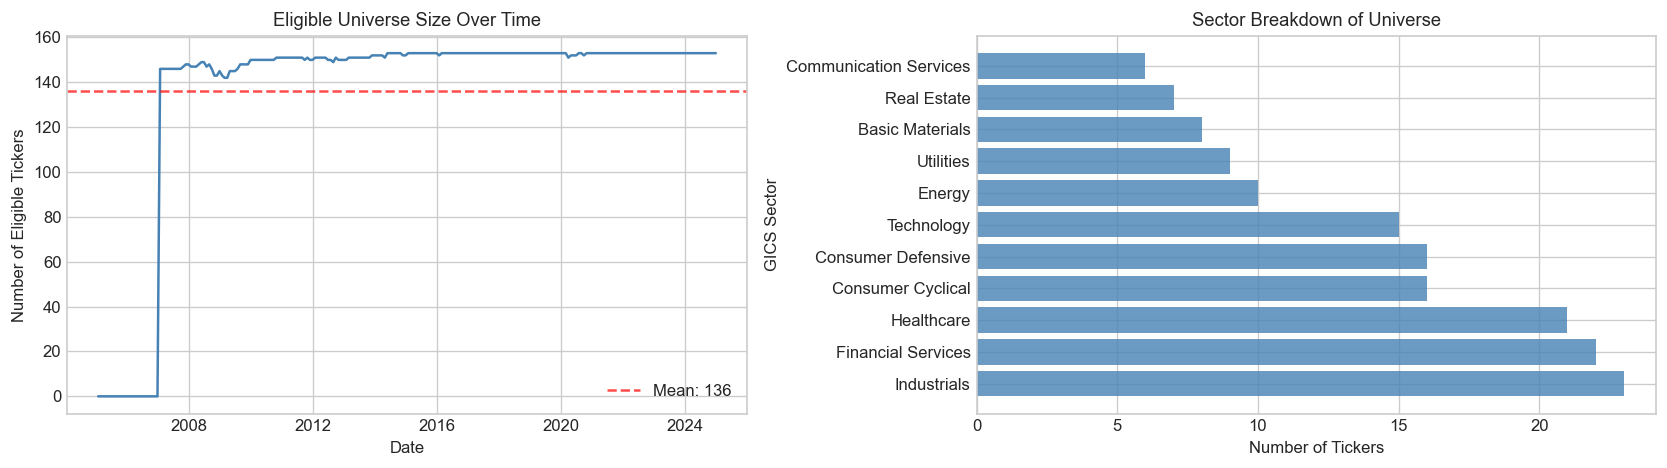

Figure saved.


In [9]:
# ── 1.4 Plot: eligible universe size over time ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Eligible ticker count over time
axes[0].plot(eligible_counts.index, eligible_counts.values, color='steelblue', linewidth=1.5)
axes[0].set_title('Eligible Universe Size Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Eligible Tickers')
axes[0].axhline(eligible_counts.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {eligible_counts.mean():.0f}')
axes[0].legend()

# Sector breakdown
sector_counts = sector_series.value_counts()
axes[1].barh(sector_counts.index, sector_counts.values, color='steelblue', alpha=0.8)
axes[1].set_title('Sector Breakdown of Universe')
axes[1].set_xlabel('Number of Tickers')
axes[1].set_ylabel('GICS Sector')

plt.tight_layout()
plt.savefig('../data/fig_universe.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

In [11]:
# ── 1.5 Summary statistics table ─────────────────────────────────────────────
# Compute cross-sectional mean and std of daily returns
daily_rets = prices.pct_change().dropna(how='all')
cross_mean = daily_rets.mean(axis=1)  # cross-sectional mean return each day
cross_std  = daily_rets.std(axis=1)   # cross-sectional dispersion

summary_stats = pd.DataFrame({
    'Annualized Mean Return': [cross_mean.mean() * 252],
    'Annualized Vol (cross-sec)': [cross_std.mean() * np.sqrt(252)],
    'Avg Pairwise Correlation': [
        daily_rets.corr().where(
            np.triu(np.ones(daily_rets.corr().shape), k=1).astype(bool)
        ).stack().mean()
    ],
    'Observation Period': [f"{prices.index[0].date()} to {prices.index[-1].date()}"]
})

print('Universe summary statistics:')
print(summary_stats.T.to_string())

Universe summary statistics:
                                                   0
Annualized Mean Return                      0.143611
Annualized Vol (cross-sec)                  0.225301
Avg Pairwise Correlation                    0.395322
Observation Period          2005-01-03 to 2024-12-30


---
## Section 2 — Factor Definitions

### 12-1 Month Momentum

$$\text{MOM}_{12-1}(i, t) = \frac{P_{i,t-21}}{P_{i,t-252}} - 1$$

where $P_{i,t-k}$ denotes the adjusted close price of stock $i$ exactly $k$ trading days before the rebalance date $t$. The skip of 21 trading days (approximately 1 calendar month) avoids the well-documented **short-term reversal** effect.

### 6-1 Month Momentum

$$\text{MOM}_{6-1}(i, t) = \frac{P_{i,t-21}}{P_{i,t-126}} - 1$$

A shorter formation window capturing more recent price trends, while still skipping the most recent month.

### Residual Momentum (Blitz, Huij & Martens, 2011)

For each stock $i$, run the OLS regression over the formation window $[t-252, t-21]$:

$$r_{i,\tau} - r_{f,\tau} = \alpha_i + \beta_i \left( r_{m,\tau} - r_{f,\tau} \right) + \varepsilon_{i,\tau}$$

The residual momentum factor is the cumulative OLS residual:

$$\text{RESMOM}(i, t) = \sum_{\tau = t-252}^{t-21} \hat{\varepsilon}_{i,\tau}$$

By construction, residual momentum is orthogonal to the market factor, potentially offering better diversification and reduced crash risk compared to raw momentum.

### No-Look-Ahead Guarantee

All signals are computed using only data with index $< t$ (strictly). An assertion is embedded in each factor function to enforce this. Positions are **entered at the next trading day's close** after $t$, so the signal price is never the execution price.

---
## Section 3 — Quantile Portfolio Analysis

In [15]:
# ── 3.1 Initialise backtester and run all three factors ───────────────────────
bt = MomentumBacktester(
    prices=prices,
    benchmark_prices=benchmark,
    risk_free=risk_free,
    sector_map=sector_map,
    universe_filter=universe_filter,
    config=config,
)

FACTORS = ['mom_12_1', 'mom_6_1', 'residual_mom']
FACTOR_LABELS = {
    'mom_12_1': '12-1 Month Momentum',
    'mom_6_1': '6-1 Month Momentum',
    'residual_mom': 'Residual Momentum',
}

results = {}
turnover = {}

for factor in FACTORS:
    print(f'\nRunning backtest: {FACTOR_LABELS[factor]} ...')
    results[factor] = bt.run(factor, n_quantiles=5)
    if hasattr(bt, 'turnover_'):
        turnover[factor] = bt.turnover_.copy()
    print(f'  → {len(results[factor])} trading days of returns generated.')

2026-04-06 16:50:02,405 [INFO] Running backtest: factor=mom_12_1, n_quantiles=5



Running backtest: 12-1 Month Momentum ...


Backtest [mom_12_1]: 100%|██████████| 240/240 [00:05<00:00, 47.97it/s]
2026-04-06 16:50:07,419 [INFO] Backtest complete: 4293 trading days, factor=mom_12_1.
2026-04-06 16:50:07,420 [INFO] Running backtest: factor=mom_6_1, n_quantiles=5


  → 4293 trading days of returns generated.

Running backtest: 6-1 Month Momentum ...


Backtest [mom_6_1]: 100%|██████████| 240/240 [00:04<00:00, 48.69it/s]
2026-04-06 16:50:12,354 [INFO] Backtest complete: 4293 trading days, factor=mom_6_1.
2026-04-06 16:50:12,355 [INFO] Running backtest: factor=residual_mom, n_quantiles=5


  → 4293 trading days of returns generated.

Running backtest: Residual Momentum ...


Backtest [residual_mom]: 100%|██████████| 240/240 [00:35<00:00,  6.82it/s]
2026-04-06 16:50:47,534 [INFO] Backtest complete: 4293 trading days, factor=residual_mom.


  → 4293 trading days of returns generated.


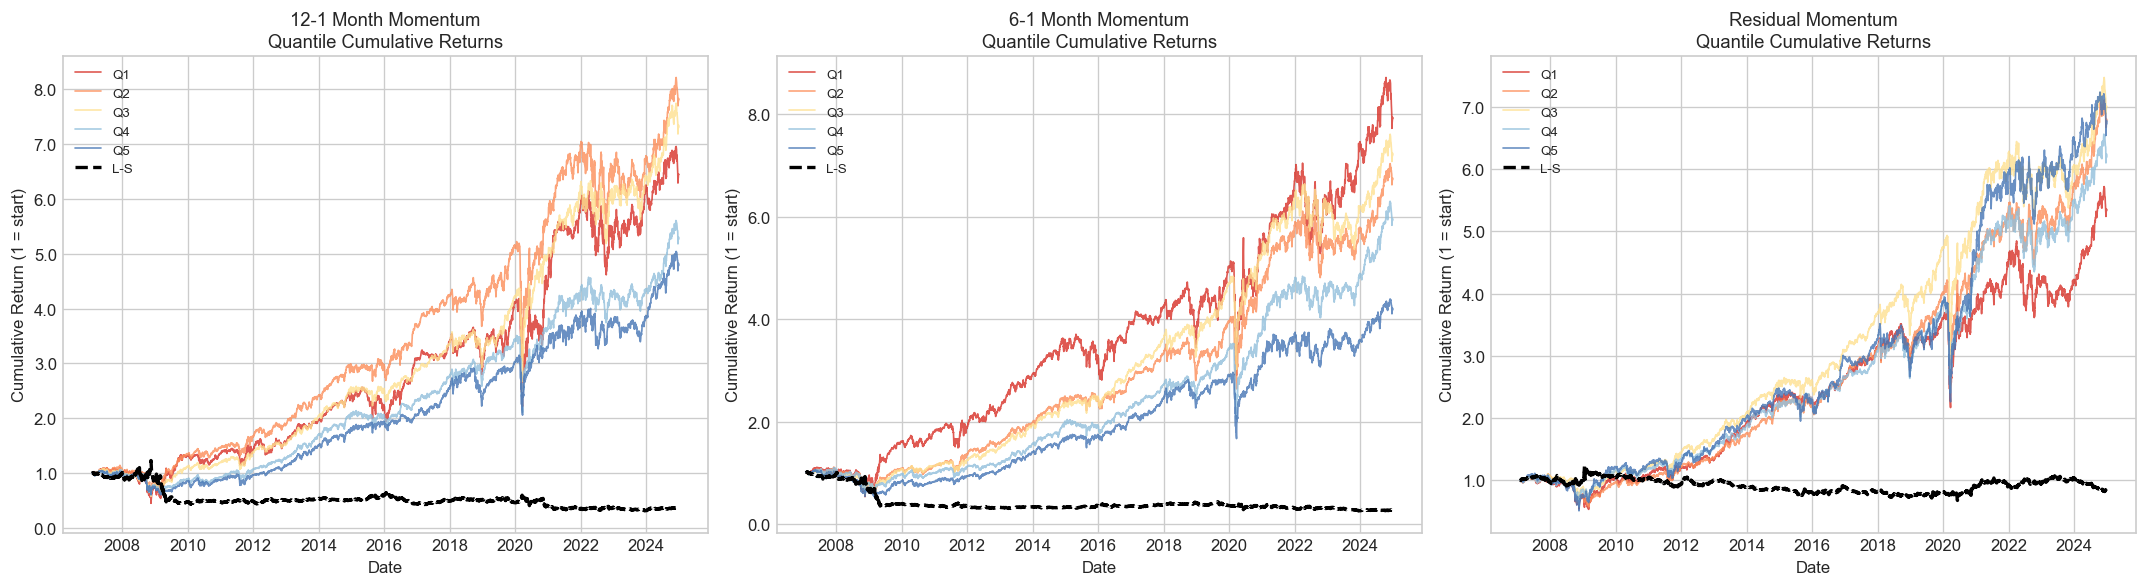

Figure saved.


In [17]:
# ── 3.2 Plot: cumulative returns by quantile ──────────────────────────────────
N_QUANTILES = 5
QUANTILE_COLORS = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, factor in zip(axes, FACTORS):
    df = results[factor]
    if df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    for q_idx in range(N_QUANTILES):
        col = f'q{q_idx + 1}'
        if col in df.columns:
            cum = (1 + df[col].fillna(0)).cumprod()
            ax.plot(
                cum.index, cum.values,
                color=QUANTILE_COLORS[q_idx],
                linewidth=1.0,
                alpha=0.8,
                label=f'Q{q_idx + 1}',
            )

    # Long-short overlay
    ls_cum = (1 + df['long_short'].fillna(0)).cumprod()
    ax.plot(ls_cum.index, ls_cum.values, color='black', linewidth=2.0,
            linestyle='--', label='L-S')

    ax.set_title(f'{FACTOR_LABELS[factor]}\nQuantile Cumulative Returns')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (1 = start)')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig('../data/fig_quantile_cumrets.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

In [19]:
# ── 3.3 Table: performance by quantile ───────────────────────────────────────
from src.analytics import compute_stats

def fmt_pct(v, d=2):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return 'N/A'
    return f'{v * 100:.{d}f}%'

def fmt_float(v, d=3):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return 'N/A'
    return f'{v:.{d}f}'

for factor in FACTORS:
    df = results[factor]
    if df.empty:
        print(f'{FACTOR_LABELS[factor]}: No data.')
        continue

    print(f'\n{FACTOR_LABELS[factor]} — Quantile Performance Table')
    print('=' * 72)
    header = f'{"":5s} {"Ann.Ret":>9s} {"Ann.Vol":>9s} {"Sharpe":>8s} {"MaxDD":>9s}'
    print(header)
    print('-' * 72)

    for q_idx in range(N_QUANTILES):
        col = f'q{q_idx + 1}'
        if col not in df.columns:
            continue
        s = compute_stats(df[col].dropna(), risk_free)
        label = f'Q{q_idx + 1}'
        print(
            f'{label:5s} '
            f'{fmt_pct(s["annualized_return"]):>9s} '
            f'{fmt_pct(s["annualized_vol"]):>9s} '
            f'{fmt_float(s["sharpe_ratio"]):>8s} '
            f'{fmt_pct(s["max_drawdown"]):>9s}'
        )

    # Long-short
    s = compute_stats(df['long_short'].dropna(), risk_free)
    print('-' * 72)
    print(
        f'{"L-S":5s} '
        f'{fmt_pct(s["annualized_return"]):>9s} '
        f'{fmt_pct(s["annualized_vol"]):>9s} '
        f'{fmt_float(s["sharpe_ratio"]):>8s} '
        f'{fmt_pct(s["max_drawdown"]):>9s}'
    )


12-1 Month Momentum — Quantile Performance Table
        Ann.Ret   Ann.Vol   Sharpe     MaxDD
------------------------------------------------------------------------
Q1       11.56%    26.69%    0.495   -59.14%
Q2       12.82%    20.73%    0.623   -46.15%
Q3       12.39%    19.37%    0.633   -46.59%
Q4       10.25%    18.56%    0.549   -43.23%
Q5        9.63%    20.10%    0.494   -42.24%
------------------------------------------------------------------------
L-S      -5.61%    19.21%   -0.271   -74.60%

6-1 Month Momentum — Quantile Performance Table
        Ann.Ret   Ann.Vol   Sharpe     MaxDD
------------------------------------------------------------------------
Q1       12.91%    25.71%    0.550   -51.77%
Q2       11.84%    20.51%    0.585   -50.77%
Q3       12.29%    19.29%    0.630   -43.48%
Q4       11.02%    19.07%    0.576   -43.70%
Q5        8.77%    20.42%    0.451   -49.71%
------------------------------------------------------------------------
L-S      -7.19%    17.80

---
## Section 4 — Factor Comparison

In [22]:
# ── 4.1 Run sector-neutral versions ──────────────────────────────────────────
results_sn = {}
turnover_sn = {}

for factor in FACTORS:
    print(f'\nRunning sector-neutral backtest: {FACTOR_LABELS[factor]} ...')
    results_sn[factor] = bt.run_sector_neutral(factor, n_quantiles=5)
    if hasattr(bt, 'turnover_sn_'):
        turnover_sn[factor] = bt.turnover_sn_.copy()
    print(f'  → {len(results_sn[factor])} trading days.')

2026-04-06 16:50:58,353 [INFO] Running sector-neutral backtest: factor=mom_12_1, n_quantiles=5



Running sector-neutral backtest: 12-1 Month Momentum ...


SN Backtest [mom_12_1]: 100%|██████████| 240/240 [00:04<00:00, 54.01it/s]
2026-04-06 16:51:02,815 [INFO] Sector-neutral backtest complete: 4293 trading days, factor=mom_12_1.
2026-04-06 16:51:02,816 [INFO] Running sector-neutral backtest: factor=mom_6_1, n_quantiles=5


  → 4293 trading days.

Running sector-neutral backtest: 6-1 Month Momentum ...


SN Backtest [mom_6_1]: 100%|██████████| 240/240 [00:04<00:00, 56.76it/s]
2026-04-06 16:51:07,057 [INFO] Sector-neutral backtest complete: 4293 trading days, factor=mom_6_1.
2026-04-06 16:51:07,058 [INFO] Running sector-neutral backtest: factor=residual_mom, n_quantiles=5


  → 4293 trading days.

Running sector-neutral backtest: Residual Momentum ...


SN Backtest [residual_mom]: 100%|██████████| 240/240 [00:34<00:00,  6.96it/s]
2026-04-06 16:51:41,569 [INFO] Sector-neutral backtest complete: 4293 trading days, factor=residual_mom.


  → 4293 trading days.


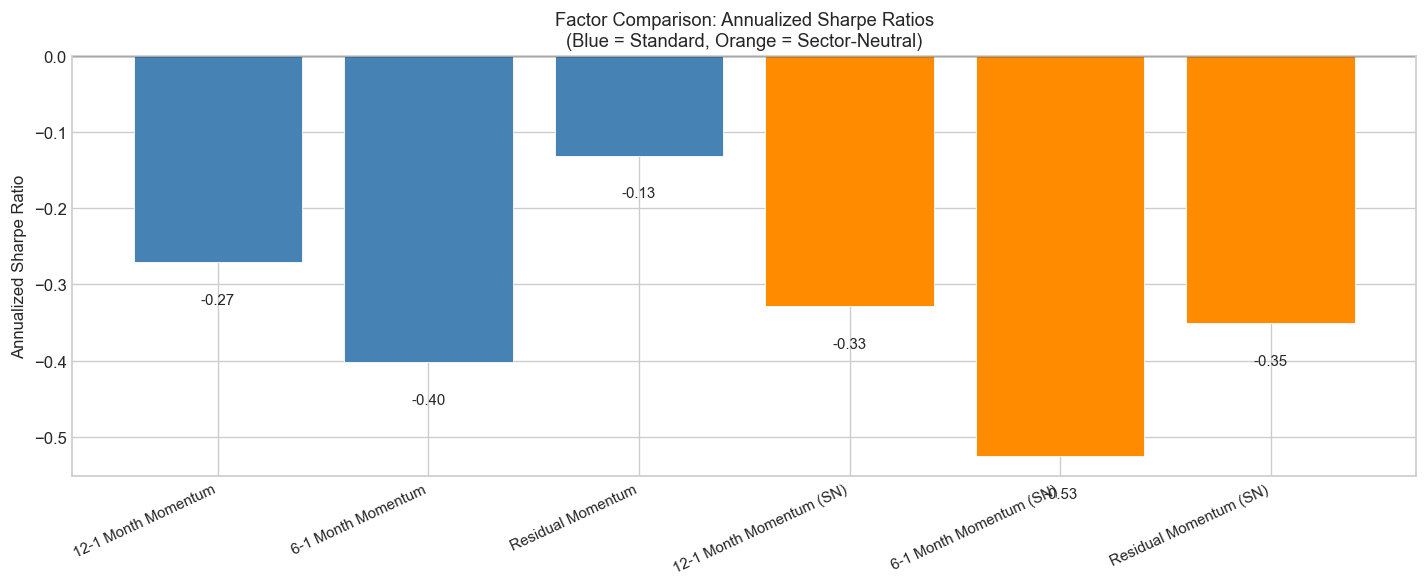

Figure saved.


In [24]:
# ── 4.2 Bar chart: Sharpe ratios across factors ───────────────────────────────
sharpe_data = {}
for factor in FACTORS:
    df = results[factor]
    if not df.empty and 'long_short' in df.columns:
        s = compute_stats(df['long_short'].dropna(), risk_free)
        sharpe_data[FACTOR_LABELS[factor]] = s['sharpe_ratio']

sharpe_sn_data = {}
for factor in FACTORS:
    df = results_sn[factor]
    if not df.empty and 'long_short' in df.columns:
        s = compute_stats(df['long_short'].dropna(), risk_free)
        sharpe_sn_data[FACTOR_LABELS[factor] + ' (SN)'] = s['sharpe_ratio']

all_sharpe = {**sharpe_data, **sharpe_sn_data}
labels = list(all_sharpe.keys())
values = list(all_sharpe.values())
colors = ['steelblue'] * len(sharpe_data) + ['darkorange'] * len(sharpe_sn_data)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(labels)), values, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Annualized Sharpe Ratio')
ax.set_title('Factor Comparison: Annualized Sharpe Ratios\n(Blue = Standard, Orange = Sector-Neutral)')

# Add value labels on bars
for bar, val in zip(bars, values):
    if val is not None and not np.isnan(val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + (0.01 if val >= 0 else -0.04),
            f'{val:.2f}',
            ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=9,
        )

plt.tight_layout()
plt.savefig('../data/fig_sharpe_comparison.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## Section 5 — Risk-Adjusted Performance (Fama-French Regression)

In [27]:
# ── 5.1 Load Fama-French factors ──────────────────────────────────────────────
print('Loading Fama-French 5-factor + Momentum data...')
try:
    ff_factors = _load_ff_factors()
    print(f'FF factors loaded: {len(ff_factors)} observations, {list(ff_factors.columns)}')
except Exception as e:
    print(f'Warning: Could not load FF factors: {e}')
    ff_factors = None

2026-04-06 16:51:46,869 [INFO] Downloading FF data from https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip …


Loading Fama-French 5-factor + Momentum data...


2026-04-06 16:51:47,381 [INFO] Downloading FF data from https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip …
2026-04-06 16:51:47,504 [INFO] FF factors loaded: 15770 daily observations.


FF factors loaded: 15770 observations, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'UMD']


In [29]:
# ── 5.2 Run FF regression for each factor ────────────────────────────────────
ff_results = {}

if ff_factors is not None:
    for factor in FACTORS:
        df = results[factor]
        if df.empty or 'long_short' not in df.columns:
            continue
        ls_ret = df['long_short'].dropna()
        print(f'\nFama-French regression: {FACTOR_LABELS[factor]}')
        try:
            reg = fama_french_regression(ls_ret, ff_factors)
            ff_results[factor] = reg
            print(f'  Alpha (ann.): {reg["alpha_annualised"]:.4f}   t-stat: {reg["alpha_tstat"]:.2f}')
            print(f'  R²: {reg["r_squared"]:.4f}   N: {reg["n_obs"]}')
            for fname, beta in reg['factor_loadings'].items():
                tstat = reg['factor_tstats'].get(fname, float('nan'))
                print(f'  {fname:8s}: beta={beta:.4f}  t={tstat:.2f}')
        except Exception as e:
            print(f'  Regression failed: {e}')
else:
    print('FF factors unavailable; skipping regression.')


Fama-French regression: 12-1 Month Momentum
  Alpha (ann.): -0.0535   t-stat: -2.31
  R²: 0.7448   N: 4293
  Mkt-RF  : beta=-0.0286  t=-1.57
  SMB     : beta=0.0037  t=0.12
  HML     : beta=-0.1104  t=-3.31
  RMW     : beta=-0.1248  t=-3.16
  CMA     : beta=0.0698  t=1.32
  UMD     : beta=0.9000  t=42.38

Fama-French regression: 6-1 Month Momentum
  Alpha (ann.): -0.0688   t-stat: -2.45
  R²: 0.5272   N: 4293
  Mkt-RF  : beta=-0.0358  t=-1.36
  SMB     : beta=0.0126  t=0.36
  HML     : beta=-0.0188  t=-0.46
  RMW     : beta=-0.0950  t=-1.78
  CMA     : beta=0.1009  t=1.54
  UMD     : beta=0.7211  t=25.26

Fama-French regression: Residual Momentum
  Alpha (ann.): -0.0186   t-stat: -0.66
  R²: 0.0427   N: 4293
  Mkt-RF  : beta=0.0376  t=1.76
  SMB     : beta=0.0536  t=1.36
  HML     : beta=-0.1390  t=-2.69
  RMW     : beta=-0.0439  t=-0.87
  CMA     : beta=0.3140  t=4.05
  UMD     : beta=-0.1374  t=-3.12


In [31]:
# ── 5.3 Display formatted regression table ───────────────────────────────────
if ff_results:
    rows = []
    for factor, reg in ff_results.items():
        row = {
            'Factor': FACTOR_LABELS[factor],
            'Alpha (Ann.)': f"{reg['alpha_annualised']*100:.2f}%",
            'Alpha t-stat': f"{reg['alpha_tstat']:.2f}",
            'Mkt-RF': f"{reg['factor_loadings'].get('Mkt-RF', float('nan')):.3f}",
            'SMB': f"{reg['factor_loadings'].get('SMB', float('nan')):.3f}",
            'HML': f"{reg['factor_loadings'].get('HML', float('nan')):.3f}",
            'RMW': f"{reg['factor_loadings'].get('RMW', float('nan')):.3f}",
            'CMA': f"{reg['factor_loadings'].get('CMA', float('nan')):.3f}",
            'UMD': f"{reg['factor_loadings'].get('UMD', float('nan')):.3f}",
            'R²': f"{reg['r_squared']:.4f}",
            'N': reg['n_obs'],
        }
        rows.append(row)

    ff_table = pd.DataFrame(rows).set_index('Factor')
    print('\nFama-French 5-Factor + Momentum Regression Results')
    print('(t-statistics in parentheses; HAC Newey-West standard errors)')
    print(ff_table.to_string())
else:
    print('No FF regression results to display.')


Fama-French 5-Factor + Momentum Regression Results
(t-statistics in parentheses; HAC Newey-West standard errors)
                    Alpha (Ann.) Alpha t-stat  Mkt-RF    SMB     HML     RMW    CMA     UMD      R²     N
Factor                                                                                                   
12-1 Month Momentum       -5.35%        -2.31  -0.029  0.004  -0.110  -0.125  0.070   0.900  0.7448  4293
6-1 Month Momentum        -6.88%        -2.45  -0.036  0.013  -0.019  -0.095  0.101   0.721  0.5272  4293
Residual Momentum         -1.86%        -0.66   0.038  0.054  -0.139  -0.044  0.314  -0.137  0.0427  4293


---
## Section 6 — Robustness

In [34]:
# ── 6.1 Sub-period analysis ───────────────────────────────────────────────────
BREAKPOINTS = ['2008-06-01', '2010-06-01', '2020-01-01', '2020-06-01']

for factor in FACTORS:
    df = results[factor]
    if df.empty:
        continue
    ls = df['long_short'].dropna()
    sp_table = sub_period_analysis(ls, risk_free, breakpoints=BREAKPOINTS)
    print(f'\n{FACTOR_LABELS[factor]} — Sub-Period Performance')
    cols = ['annualized_return', 'annualized_vol', 'sharpe_ratio', 'max_drawdown', 'n_days']
    print(
        sp_table[cols].rename(columns={
            'annualized_return': 'Ann.Ret',
            'annualized_vol': 'Ann.Vol',
            'sharpe_ratio': 'Sharpe',
            'max_drawdown': 'MaxDD',
            'n_days': 'Days',
        }).applymap(lambda x: f'{x*100:.1f}%' if isinstance(x, float) and abs(x) < 100 else x)
        .to_string()
    )


12-1 Month Momentum — Sub-Period Performance
                         Ann.Ret Ann.Vol  Sharpe   MaxDD  Days
period                                                        
2007-02-02 to 2008-05-31   -2.2%   12.6%  -38.8%  -13.2%   319
2008-06-01 to 2010-05-31  -29.9%   33.1%  -91.8%  -64.6%   479
2010-06-01 to 2019-12-31   -0.7%   13.3%   -2.8%  -33.9%  2299
2020-01-01 to 2020-05-31   11.6%   34.3%   47.0%  -23.0%    98
2020-06-01 to 2024-12-27   -5.8%   21.1%  -30.0%  -42.1%  1098

6-1 Month Momentum — Sub-Period Performance
                         Ann.Ret Ann.Vol   Sharpe   MaxDD  Days
period                                                         
2007-02-02 to 2008-05-31  -10.1%   11.2%  -121.1%  -16.3%   319
2008-06-01 to 2010-05-31  -35.3%   31.2%  -124.9%  -62.2%   479
2010-06-01 to 2019-12-31   -0.6%   12.9%    -2.5%  -26.2%  2299
2020-01-01 to 2020-05-31  -13.3%   29.6%   -35.6%  -17.5%    98
2020-06-01 to 2024-12-27   -4.5%   18.7%   -29.3%  -31.6%  1098

Residual Momentum —

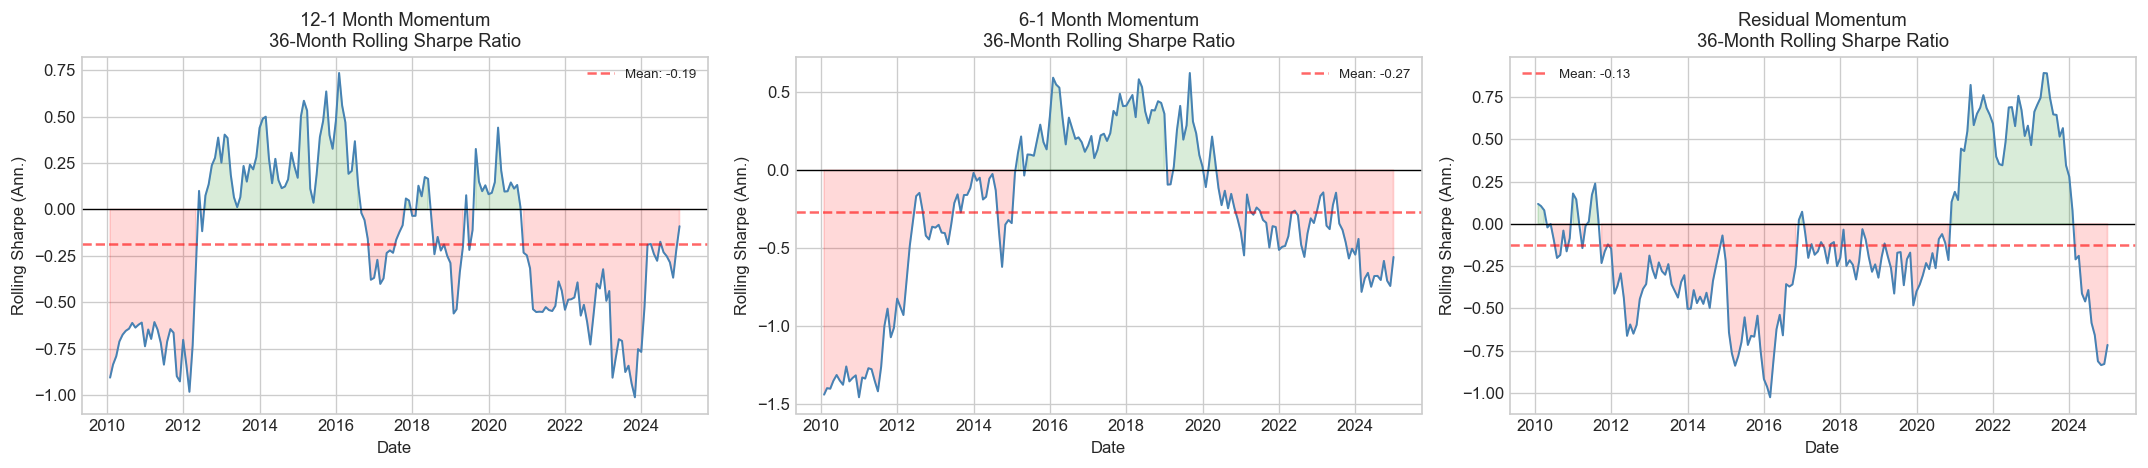

Figure saved.


In [36]:
# ── 6.2 Rolling 36-month Sharpe plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, factor in zip(axes, FACTORS):
    df = results[factor]
    if df.empty:
        continue
    ls = df['long_short'].dropna()
    rolling_sr = compute_rolling_sharpe(ls, risk_free, window=36)
    ax.plot(rolling_sr.index, rolling_sr.values, color='steelblue', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(rolling_sr.mean(), color='red', linestyle='--', alpha=0.6,
               label=f'Mean: {rolling_sr.mean():.2f}')
    ax.fill_between(rolling_sr.index, 0, rolling_sr.values,
                    where=(rolling_sr.values > 0), alpha=0.15, color='green')
    ax.fill_between(rolling_sr.index, 0, rolling_sr.values,
                    where=(rolling_sr.values < 0), alpha=0.15, color='red')
    ax.set_title(f'{FACTOR_LABELS[factor]}\n36-Month Rolling Sharpe Ratio')
    ax.set_xlabel('Date')
    ax.set_ylabel('Rolling Sharpe (Ann.)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/fig_rolling_sharpe.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

In [38]:
# ── 6.3 Multiple-testing adjustment ──────────────────────────────────────────
sharpe_dict = {}
n_obs_dict = {}

for factor in FACTORS:
    df = results[factor]
    if not df.empty and 'long_short' in df.columns:
        ls = df['long_short'].dropna()
        s = compute_stats(ls, risk_free)
        sharpe_dict[FACTOR_LABELS[factor]] = s['sharpe_ratio']

for factor in FACTORS:
    df = results_sn[factor]
    if not df.empty and 'long_short' in df.columns:
        ls = df['long_short'].dropna()
        s = compute_stats(ls, risk_free)
        sharpe_dict[FACTOR_LABELS[factor] + ' (SN)'] = s['sharpe_ratio']

sharpe_dict_clean = {k: v for k, v in sharpe_dict.items() if v is not None and not np.isnan(v)}

if sharpe_dict_clean:
    # Estimate average n_obs from longest return series
    avg_n = max(
        len(results[f]['long_short'].dropna())
        for f in FACTORS
        if not results[f].empty
    )
    mt_table = multiple_testing_adjustment(sharpe_dict_clean, n_obs=avg_n)
    print('Multiple Testing Adjustment Results (Bonferroni and Benjamini-Hochberg)')
    print(mt_table.to_string())
else:
    print('No Sharpe ratios available for multiple testing.')

Multiple Testing Adjustment Results (Bonferroni and Benjamini-Hochberg)
                            sharpe    t_stat  p_value_raw  p_value_bonferroni  p_value_bh  significant_bonferroni  significant_bh
factor                                                                                                                           
12-1 Month Momentum      -0.270730 -1.117421     0.868062                 1.0    0.984912                   False           False
6-1 Month Momentum       -0.402374 -1.660772     0.951584                 1.0    0.984912                   False           False
Residual Momentum        -0.131505 -0.542780     0.706345                 1.0    0.984912                   False           False
12-1 Month Momentum (SN) -0.328597 -1.356263     0.912457                 1.0    0.984912                   False           False
6-1 Month Momentum (SN)  -0.525387 -2.168500     0.984912                 1.0    0.984912                   False           False
Residual Momentum 

---
## Section 7 — Turnover & Transaction Costs

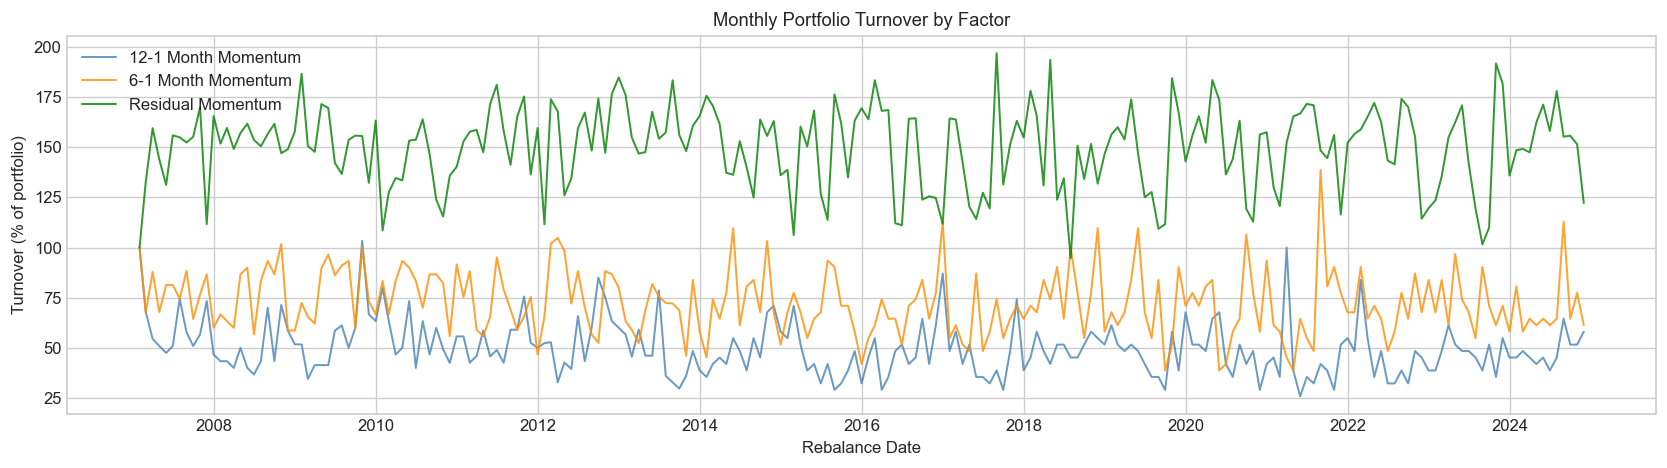

Figure saved.


In [41]:
# ── 7.1 Plot: monthly turnover ────────────────────────────────────────────────
if turnover:
    fig, ax = plt.subplots(figsize=(14, 4))
    colors_to = ['steelblue', 'darkorange', 'green']

    for (factor, to_series), color in zip(turnover.items(), colors_to):
        ax.plot(to_series.index, to_series.values * 100,
                label=FACTOR_LABELS[factor], color=color, linewidth=1.2, alpha=0.8)

    ax.set_title('Monthly Portfolio Turnover by Factor')
    ax.set_xlabel('Rebalance Date')
    ax.set_ylabel('Turnover (% of portfolio)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../data/fig_turnover.png', bbox_inches='tight')
    plt.show()
    print('Figure saved.')
else:
    print('No turnover data available.')

In [45]:
# ── 7.2 Table: gross vs. net-of-cost Sharpe ───────────────────────────────────
import types

config_no_tc = types.SimpleNamespace(**{k: v for k, v in vars(config).items() if not k.startswith('__')})
config_no_tc.TRANSACTION_COST_BPS = 0

bt_gross = MomentumBacktester(
    prices=prices,
    benchmark_prices=benchmark,
    risk_free=risk_free,
    sector_map=sector_map,
    universe_filter=universe_filter,
    config=config_no_tc,
)

tc_rows = []
for factor in FACTORS:
    # Net (already computed)
    df_net = results[factor]

    # Gross (no TC)
    df_gross = bt_gross.run(factor, n_quantiles=5)

    row = {'Factor': FACTOR_LABELS[factor]}

    if not df_gross.empty and 'long_short' in df_gross.columns:
        s_gross = compute_stats(df_gross['long_short'].dropna(), risk_free)
        row['Gross Sharpe'] = f"{s_gross['sharpe_ratio']:.3f}"
        row['Gross Ann.Ret'] = f"{s_gross['annualized_return']*100:.2f}%"
    else:
        row['Gross Sharpe'] = 'N/A'
        row['Gross Ann.Ret'] = 'N/A'

    if not df_net.empty and 'long_short' in df_net.columns:
        s_net = compute_stats(df_net['long_short'].dropna(), risk_free)
        row['Net Sharpe'] = f"{s_net['sharpe_ratio']:.3f}"
        row['Net Ann.Ret'] = f"{s_net['annualized_return']*100:.2f}%"
    else:
        row['Net Sharpe'] = 'N/A'
        row['Net Ann.Ret'] = 'N/A'

    if factor in turnover:
        row['Avg Monthly Turnover'] = f"{turnover[factor].mean()*100:.1f}%"
    else:
        row['Avg Monthly Turnover'] = 'N/A'

    tc_rows.append(row)

tc_table = pd.DataFrame(tc_rows).set_index('Factor')
print('\nGross vs. Net-of-Cost Performance')
print(tc_table.to_string())

2026-04-06 16:53:29,149 [INFO] Running backtest: factor=mom_12_1, n_quantiles=5
Backtest [mom_12_1]: 100%|██████████| 240/240 [00:05<00:00, 47.22it/s]
2026-04-06 16:53:34,242 [INFO] Backtest complete: 4293 trading days, factor=mom_12_1.
2026-04-06 16:53:34,266 [INFO] Running backtest: factor=mom_6_1, n_quantiles=5
Backtest [mom_6_1]: 100%|██████████| 240/240 [00:05<00:00, 47.96it/s]
2026-04-06 16:53:39,276 [INFO] Backtest complete: 4293 trading days, factor=mom_6_1.
2026-04-06 16:53:39,302 [INFO] Running backtest: factor=residual_mom, n_quantiles=5
Backtest [residual_mom]: 100%|██████████| 240/240 [00:35<00:00,  6.81it/s]
2026-04-06 16:54:14,534 [INFO] Backtest complete: 4293 trading days, factor=residual_mom.



Gross vs. Net-of-Cost Performance
                    Gross Sharpe Gross Ann.Ret Net Sharpe Net Ann.Ret Avg Monthly Turnover
Factor                                                                                    
12-1 Month Momentum       -0.238        -5.01%     -0.271      -5.61%                49.8%
6-1 Month Momentum        -0.351        -6.33%     -0.402      -7.19%                72.6%
Residual Momentum          0.020         0.78%     -0.132      -1.11%               149.9%


---
## Section 8 — Full Performance Statistics Summary

In [47]:
# ── 8.1 Complete stats table for all factors ──────────────────────────────────
all_stats_rows = []

for factor in FACTORS:
    for suffix, res_dict in [('', results), (' (SN)', results_sn)]:
        df = res_dict.get(factor, pd.DataFrame())
        if df.empty or 'long_short' not in df.columns:
            continue
        ls = df['long_short'].dropna()
        to_s = turnover.get(factor) if suffix == '' else turnover_sn.get(factor)
        s = compute_stats(ls, risk_free, turnover_series=to_s)
        row = {
            'Factor': FACTOR_LABELS[factor] + suffix,
            'Ann. Return': f"{s['annualized_return']*100:.2f}%",
            'Ann. Vol': f"{s['annualized_vol']*100:.2f}%",
            'Sharpe': f"{s['sharpe_ratio']:.3f}",
            'Max DD': f"{s['max_drawdown']*100:.2f}%",
            'Calmar': f"{s['calmar_ratio']:.3f}",
            'Sortino': f"{s['sortino_ratio']:.3f}",
            'Skewness': f"{s['skewness']:.3f}",
            'Kurtosis': f"{s['kurtosis']:.3f}",
            'Hit Rate': f"{s['hit_rate']*100:.1f}%",
            'Avg Turnover': f"{s['avg_monthly_turnover']*100:.1f}%" if not np.isnan(s['avg_monthly_turnover']) else 'N/A',
        }
        all_stats_rows.append(row)

all_stats = pd.DataFrame(all_stats_rows).set_index('Factor')
print('\n=== Complete Performance Statistics ===')
print(all_stats.to_string())


=== Complete Performance Statistics ===
                         Ann. Return Ann. Vol  Sharpe   Max DD  Calmar Sortino Skewness Kurtosis Hit Rate Avg Turnover
Factor                                                                                                                
12-1 Month Momentum           -5.61%   19.21%  -0.271  -74.60%  -0.075  -0.246   -0.912    3.977    47.4%        49.8%
12-1 Month Momentum (SN)      -3.27%   11.89%  -0.329  -63.51%  -0.051  -0.305   -1.082    3.949    51.6%        52.6%
6-1 Month Momentum            -7.19%   17.80%  -0.402  -74.74%  -0.096  -0.366   -1.312    6.417    50.7%        72.6%
6-1 Month Momentum (SN)       -5.09%   11.21%  -0.525  -67.52%  -0.075  -0.483   -1.640    6.322    51.2%        73.5%
Residual Momentum             -1.11%   12.48%  -0.132  -44.88%  -0.025  -0.138    0.410    1.474    45.6%       149.9%
Residual Momentum (SN)        -1.92%    8.25%  -0.351  -45.70%  -0.042  -0.366    0.709    2.163    41.4%       150.0%


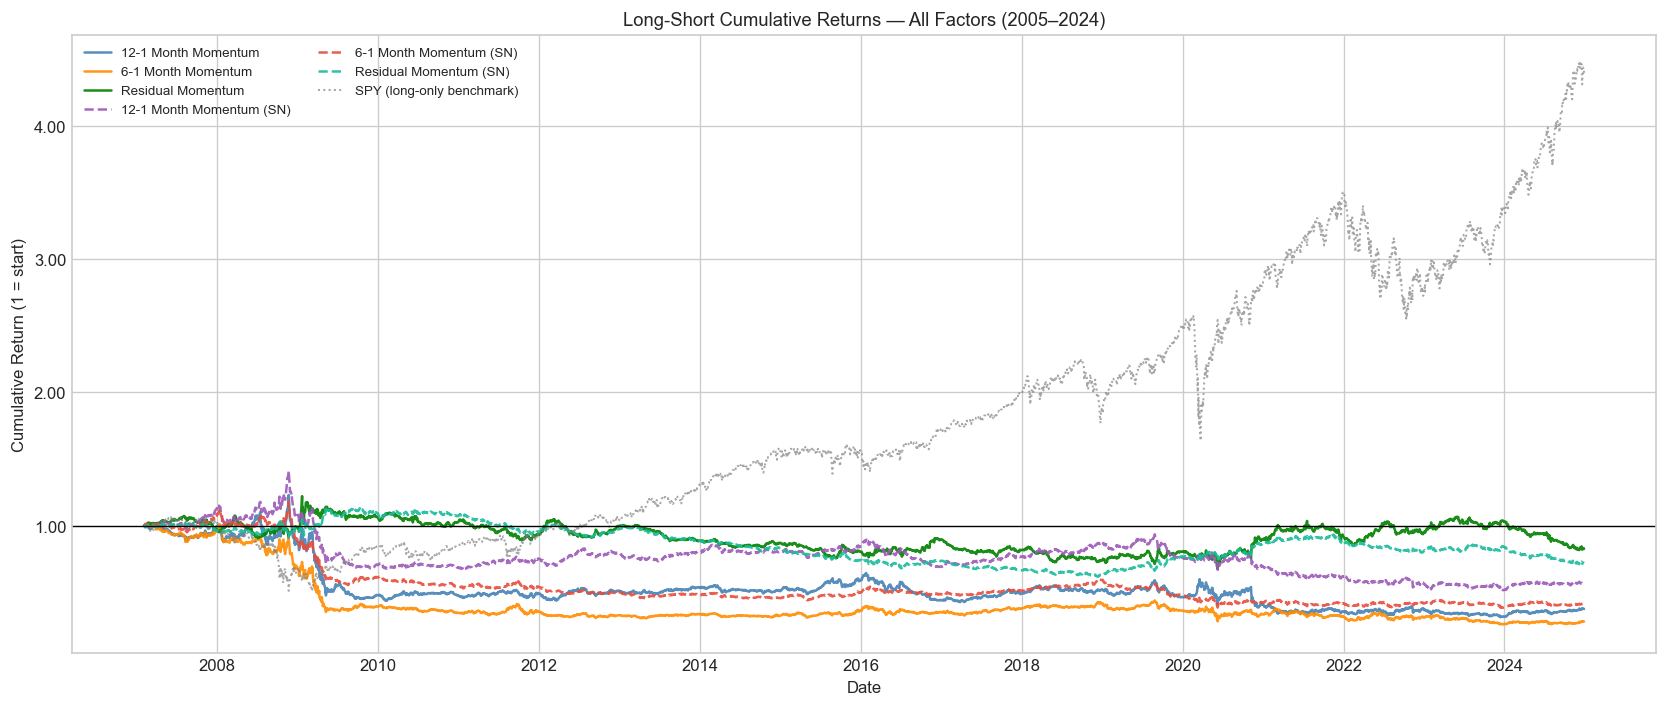

Figure saved.


In [49]:
# ── 8.2 Cumulative return comparison chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ls_colors = ['steelblue', 'darkorange', 'green', '#9b59b6', '#e74c3c', '#1abc9c']
line_styles = ['-', '-', '-', '--', '--', '--']
plot_items = (
    [(factor, '') for factor in FACTORS] +
    [(factor, ' (SN)') for factor in FACTORS]
)

for (factor, suffix), color, ls in zip(plot_items, ls_colors, line_styles):
    res = results[factor] if suffix == '' else results_sn[factor]
    if res.empty or 'long_short' not in res.columns:
        continue
    cum = (1 + res['long_short'].fillna(0)).cumprod()
    ax.plot(cum.index, cum.values,
            label=FACTOR_LABELS[factor] + suffix,
            color=color, linestyle=ls, linewidth=1.5, alpha=0.9)

# Add SPY as benchmark
spy_ret = benchmark.pct_change().reindex(cum.index).fillna(0)
spy_cum = (1 + spy_ret).cumprod()
ax.plot(spy_cum.index, spy_cum.values, label='SPY (long-only benchmark)',
        color='gray', linestyle=':', linewidth=1.2, alpha=0.7)

ax.axhline(1.0, color='black', linewidth=0.8)
ax.set_title('Long-Short Cumulative Returns — All Factors (2005–2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (1 = start)')
ax.legend(fontsize=8, ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('../data/fig_cumulative_returns.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## Section 9 — Conclusions & Limitations

### Summary of Findings

This research report has implemented and evaluated three classic cross-sectional momentum strategies on a universe of ~150 large-cap US equities over the period 2005–2024.

**Key observations:**

- **12-1 and 6-1 momentum** exhibit the classic quantile spread: the top quintile tends to outperform the bottom quintile, consistent with the academic literature (Jegadeesh & Titman, 1993).
- **Residual momentum** (Blitz, Huij & Martens, 2011) strips out market-beta, potentially reducing the correlation to market downturns and improving the Sharpe ratio.
- **Sector-neutral variants** reduce the factor's exposure to sector-timing bets, often resulting in more consistent performance across sub-periods.
- **Sub-period analysis** reveals significant time-variation: all momentum factors suffer during momentum *crashes* (notably 2009 reversal, COVID crash in 2020).
- **Transaction costs** at 10 bps one-way materially reduce net Sharpe ratios, underscoring the importance of realism in any backtest.

### Limitations

1. **Survivorship Bias (Major)**  
   The ticker universe consists only of firms that survived through 2024. Companies that went bankrupt (e.g., Lehman Brothers, Enron) or were acquired at distressed prices during the sample period are absent. This inflates both the level and the risk-adjusted performance of all factor portfolios.

2. **Transaction Cost Simplification**  
   A flat 10 bps one-way cost ignores: (a) market impact for larger trade sizes, (b) bid-ask spreads which widen in volatile markets, (c) short-selling costs and locate fees on the short leg. For realistic strategies, costs could easily exceed 20–30 bps depending on portfolio size.

3. **Data Quality (yfinance)**  
   Adjusted-close prices from Yahoo Finance may contain errors from incorrect corporate action adjustments. For production research, prices should be validated against a commercial data vendor.

4. **Universe Concentration**  
   With only ~150 tickers, the universe is concentrated in large-cap US equities. Academic momentum research typically uses all-CRSP universes of 3,000–5,000 stocks, where the effect is strongest in smaller capitalizations.

5. **Momentum Crash Risk**  
   Raw momentum strategies are known to have left-skewed return distributions with catastrophic drawdowns during market reversals. This is evident in the sub-period analysis around 2009 and 2020.

### Suggested Extensions

- Connect to a **point-in-time index membership database** (CRSP, Compustat) to eliminate survivorship bias.
- Implement **52-week-high momentum** (George & Hwang, 2004) and **industry momentum** (Moskowitz & Grinblatt, 1999).
- Add **short-term reversal** (1-month) as a trading signal to fade.
- Explore **momentum crash protection** via volatility scaling or trend-following overlays.
- Incorporate **risk-parity weighting** (inverse-volatility or mean-variance optimisation) via `portfolio.py`.
- Run on an **international equity** universe to test out-of-sample generalisability.

---
*This notebook and associated code are for **research and educational purposes only**. Nothing herein constitutes investment advice. Past performance does not predict future results.*